# Import statement

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

Read data

In [2]:
data = pd.read_csv('/content/Mall_Customers.csv')

In [3]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Univariate Analysis


In [4]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


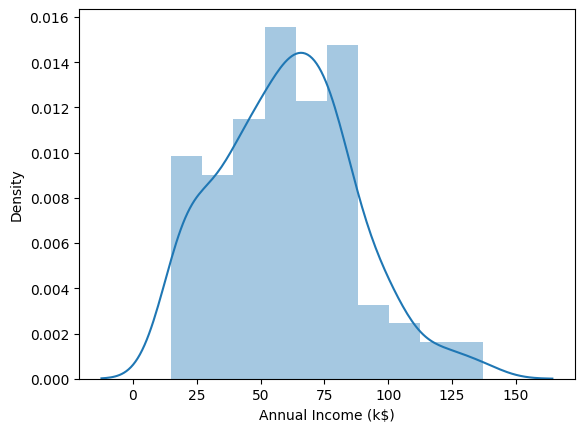

In [12]:
sns.distplot(data['Annual Income (k$)']);

In [16]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

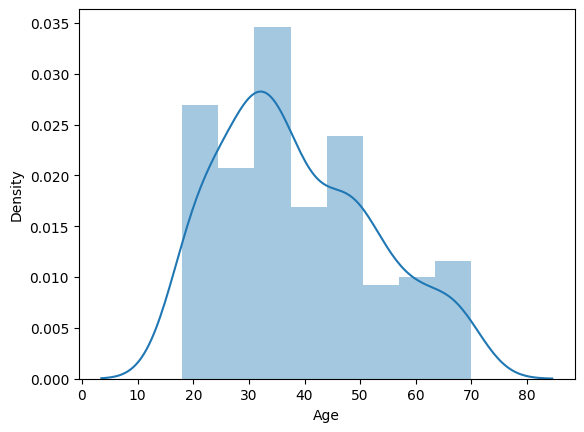

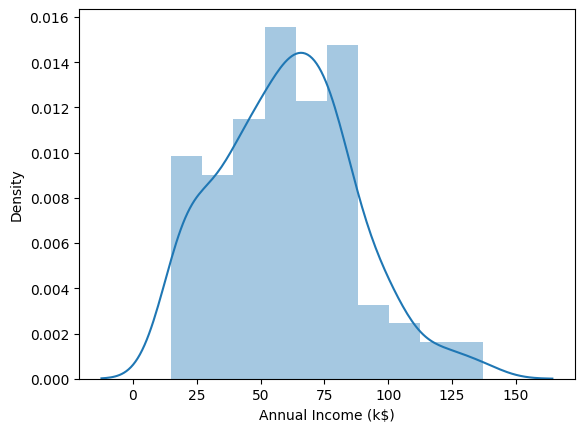

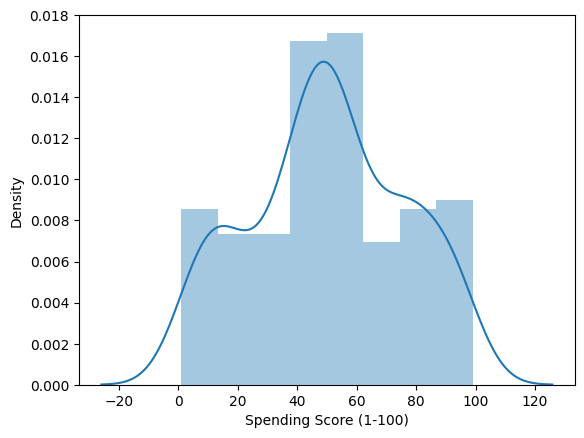

In [26]:
columns = ['Age', 'Annual Income (k$)','Spending Score (1-100)']
for column in columns:
  plt.figure()
  sns.distplot(data[column])

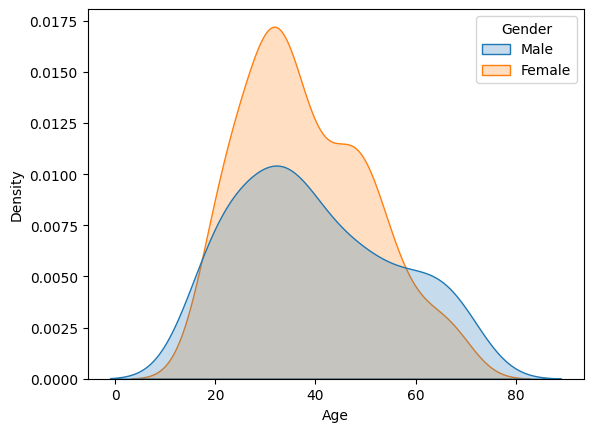

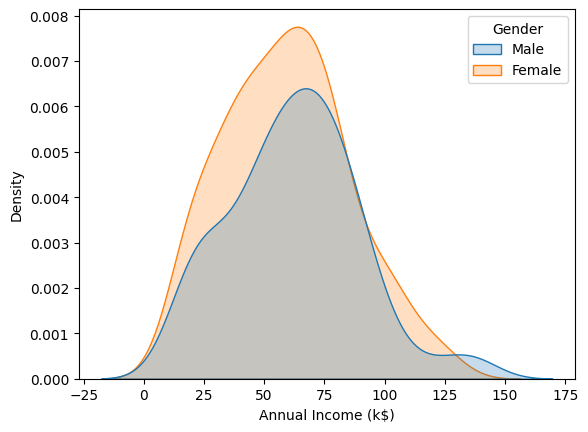

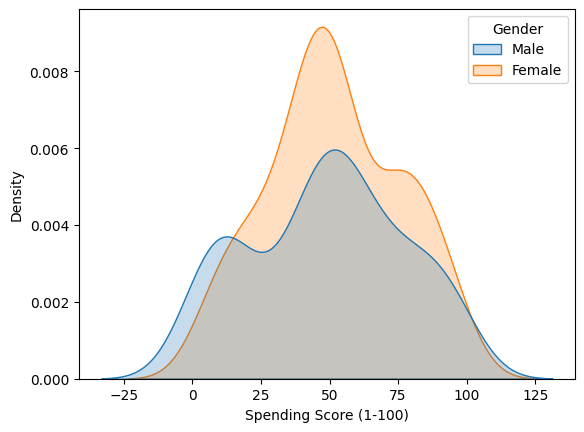

In [32]:
for column in columns:
  plt.figure()
  sns.kdeplot(x=data[column], hue=data['Gender'], shade=True)

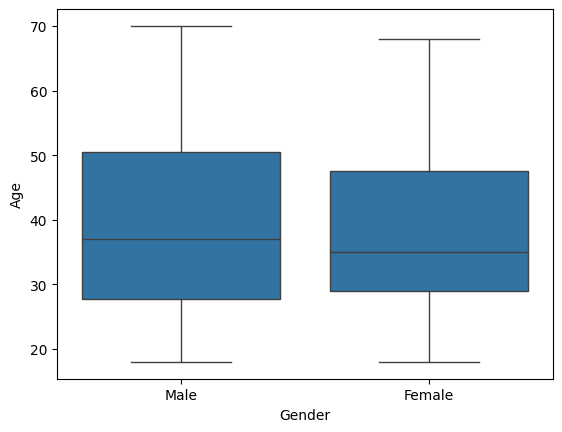

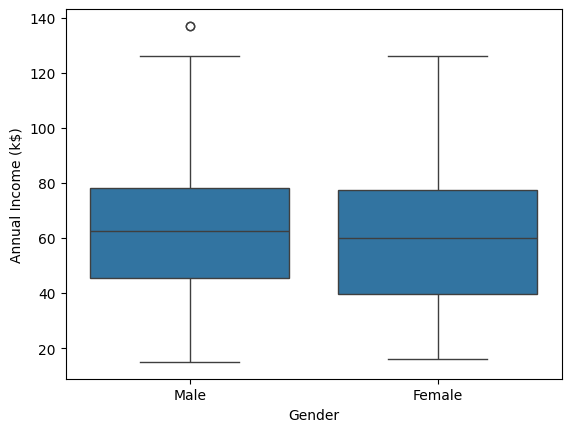

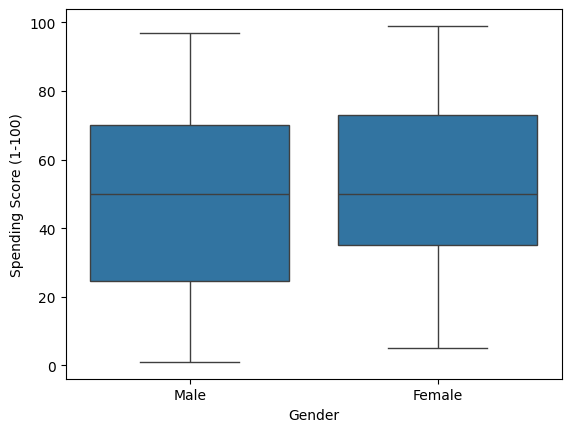

In [33]:
for column in columns:
  plt.figure()
  sns.boxplot(data=data, x='Gender', y=data[column])

In [34]:
data['Gender'].value_counts(normalize=True)

,proportion
Gender,
Female,0.56
Male,0.44


# Bivariate Analysis

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

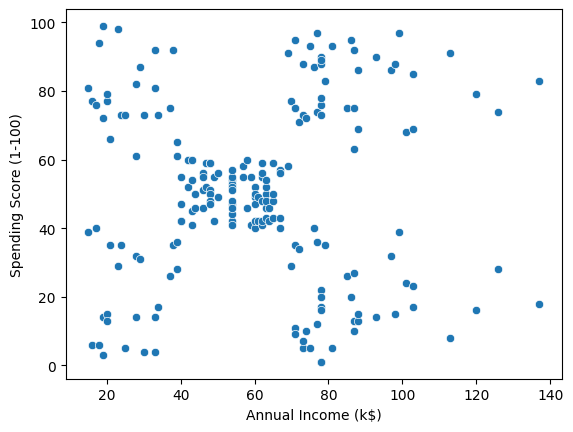

In [35]:
sns.scatterplot(x=data['Annual Income (k$)'], y=data['Spending Score (1-100)'])

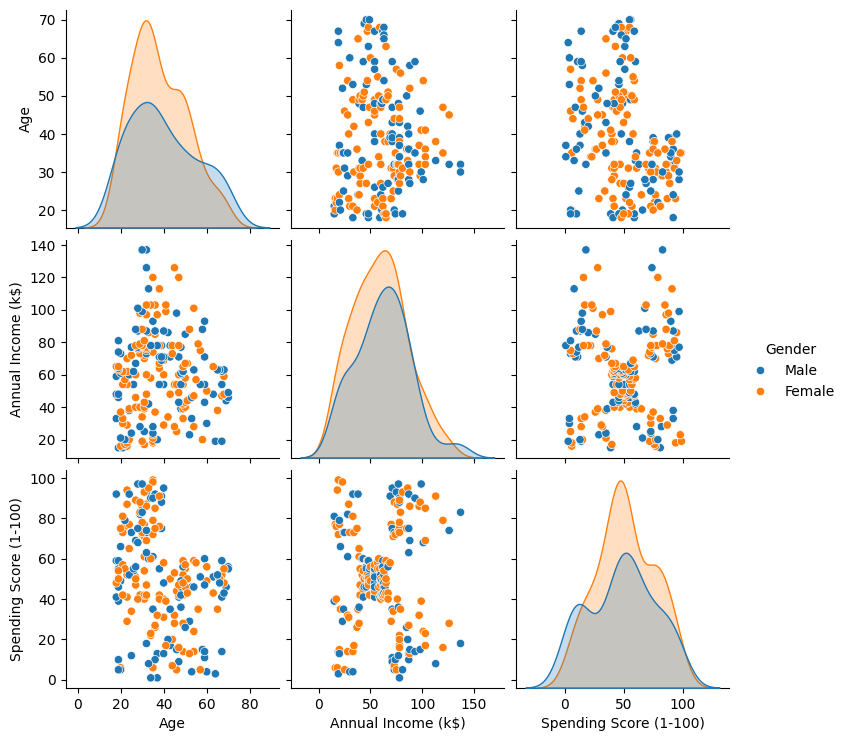

In [40]:
sns.pairplot(data.drop('CustomerID', axis=1), hue='Gender')

In [45]:
data.groupby('Gender')[columns].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


In [47]:
data[columns].corr()

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


<Axes: >

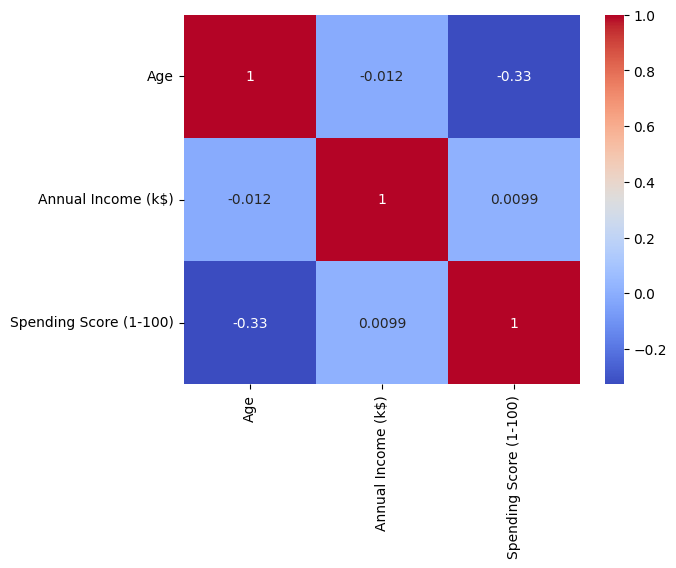

In [48]:
sns.heatmap(data[columns].corr(), annot=True, cmap='coolwarm')

# Clustering - Univariate, Bivariate, Multivariate

In [50]:
clustering1 = KMeans(n_clusters=3)

In [52]:
clustering1.fit(data[['Annual Income (k$)']])

KMeans(n_clusters=3)

In [53]:
clustering1.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=int32)

In [54]:
data['Income Cluster'] = clustering1.labels_
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [55]:
data['Income Cluster'].value_counts()

,count
Income Cluster,
1,86
2,58
0,56


In [56]:
clustering1.inertia_

25640.457784396807

In [58]:
inertia_scores = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(data[['Annual Income (k$)']])
  inertia_scores.append(kmeans.inertia_)

In [59]:
inertia_scores

[137277.2800000002,
 48968.020808323316,
 25640.457784396807,
 14647.235170393054,
 8675.385020242913,
 5811.503677672444,
 4448.461152882205,
 3505.2566544566516,
 2220.6341269841287,
 1782.5832112332112]

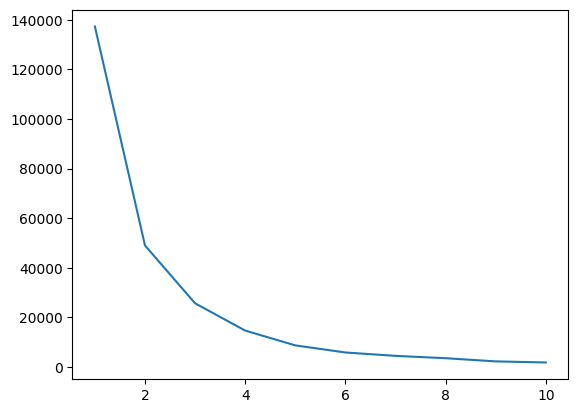

In [60]:
plt.plot(range(1, 11), inertia_scores)

In [62]:
data.groupby('Income Cluster')[columns].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Income Cluster,,,
0,36.910714,92.142857,50.517857
1,41.279070,60.906977,50.337209
2,37.120690,29.551724,49.689655


Bivariate Clustering

In [65]:
clustering2 = KMeans(n_clusters=5)
clustering2.fit(data[['Annual Income (k$)', 'Spending Score (1-100)']])
data['Spending & Income Cluster'] = clustering2.labels_
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending & Income Cluster
0,1,Male,19,15,39,2,0
1,2,Male,21,15,81,2,3
2,3,Female,20,16,6,2,0
3,4,Female,23,16,77,2,3
4,5,Female,31,17,40,2,0


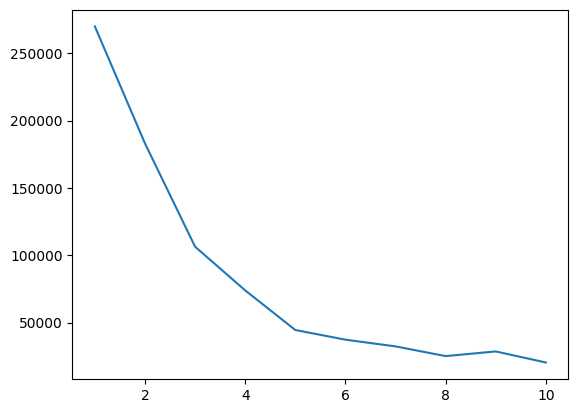

In [67]:
inertia_scores2 = []
for i in range(1, 11):
  kmeans2 = KMeans(n_clusters=i)
  kmeans2.fit(data[['Annual Income (k$)', 'Spending Score (1-100)']])
  inertia_scores2.append(kmeans2.inertia_)
plt.plot(range(1, 11), inertia_scores2)

In [69]:
centers = pd.DataFrame(clustering2.cluster_centers_)
centers.columns = ['x', 'y']

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

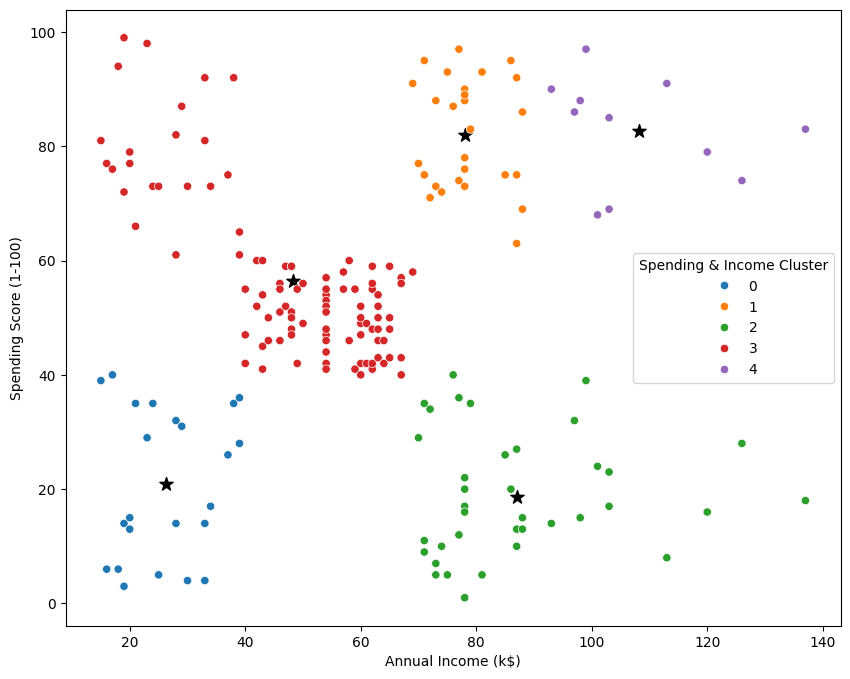

In [76]:
plt.figure(figsize=(10, 8))
plt.scatter(x=centers['x'], y=centers['y'], s=100, c='black', marker='*')
sns.scatterplot(data=data, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Spending & Income Cluster', palette='tab10')

In [81]:
pd.crosstab(data['Spending & Income Cluster'], data['Gender'], normalize='index')

Gender,Female,Male
Spending & Income Cluster,,
0,0.608696,0.391304
1,0.535714,0.464286
2,0.473684,0.526316
3,0.590000,0.410000
4,0.545455,0.454545


In [83]:
data.groupby('Spending & Income Cluster')[columns].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Spending & Income Cluster,,,
0,45.217391,26.304348,20.913043
1,32.785714,78.035714,81.892857
2,40.394737,87.000000,18.631579
3,39.200000,48.260000,56.480000
4,32.454545,108.181818,82.727273


Mulivariate clustering

In [86]:
scale = StandardScaler()

In [103]:
df = pd.get_dummies(data, drop_first=True, dtype='int')
df = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)',
               'Gender_Male']]
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


In [104]:
df = pd.DataFrame(scale.fit_transform(df))
df.head()

,0,1,2,3
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


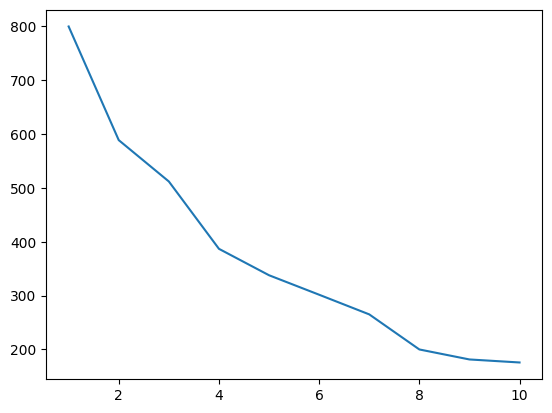

In [106]:
inertia_scores3 = []
for i in range(1, 11):
  kmeans3 = KMeans(n_clusters=i)
  kmeans3.fit(df)
  inertia_scores3.append(kmeans3.inertia_)
plt.plot(range(1, 11), inertia_scores3)